In [ ]:
#@title Importing packages
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import functools
import os
from google.colab import drive
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
# import tqdm
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
#@title Defining a time-dependent score-based model (double click to expand or collapse)

class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""
  def __init__(self, embed_dim, scale=30.):
    super().__init__()
    # Randomly sample weights during initialization. These weights are fixed
    # during optimization and are not trainable.
    self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
  def forward(self, x):
    x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
  """A fully connected layer that reshapes outputs to feature maps."""
  def __init__(self, input_dim, output_dim):
    super().__init__()
    self.dense = nn.Linear(input_dim, output_dim)
  def forward(self, x):
    return self.dense(x)[..., None, None]

class ScoreNet(nn.Module):
  """A time-dependent score-based model built upon U-Net architecture."""

  def __init__(self, marginal_prob_std, channels=[32, 64, 128, 256], embed_dim=256):
    """Initialize a time-dependent score-based network.

    Args:
      marginal_prob_std: A function that takes time t and gives the standard
        deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
      channels: The number of channels for feature maps of each resolution.
      embed_dim: The dimensionality of Gaussian random feature embeddings.
    """
    super().__init__()
    # Gaussian random feature embedding layer for time
    self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
         nn.Linear(embed_dim, embed_dim))
    # Encoding layers where the resolution decreases
    self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
    self.dense1 = Dense(embed_dim, channels[0])
    self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
    self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
    self.dense2 = Dense(embed_dim, channels[1])
    self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
    self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
    self.dense3 = Dense(embed_dim, channels[2])
    self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
    self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
    self.dense4 = Dense(embed_dim, channels[3])
    self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])

    # Decoding layers where the resolution increases
    self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False)
    self.dense5 = Dense(embed_dim, channels[2])
    self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
    self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)
    self.dense6 = Dense(embed_dim, channels[1])
    self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
    self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)
    self.dense7 = Dense(embed_dim, channels[0])
    self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
    self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)

    # The swish activation function
    self.act = lambda x: x * torch.sigmoid(x)
    self.marginal_prob_std = marginal_prob_std

  def forward(self, x, t):
    # Obtain the Gaussian random feature embedding for t
    embed = self.act(self.embed(t))
    # Encoding path
    h1 = self.conv1(x)
    ## Incorporate information from t
    h1 += self.dense1(embed)
    ## Group normalization
    h1 = self.gnorm1(h1)
    h1 = self.act(h1)
    h2 = self.conv2(h1)
    h2 += self.dense2(embed)
    h2 = self.gnorm2(h2)
    h2 = self.act(h2)
    h3 = self.conv3(h2)
    h3 += self.dense3(embed)
    h3 = self.gnorm3(h3)
    h3 = self.act(h3)
    h4 = self.conv4(h3)
    h4 += self.dense4(embed)
    h4 = self.gnorm4(h4)
    h4 = self.act(h4)

    # Decoding path
    h = self.tconv4(h4)
    ## Skip connection from the encoding path
    h += self.dense5(embed)
    h = self.tgnorm4(h)
    h = self.act(h)
    h = self.tconv3(torch.cat([h, h3], dim=1))
    h += self.dense6(embed)
    h = self.tgnorm3(h)
    h = self.act(h)
    h = self.tconv2(torch.cat([h, h2], dim=1))
    h += self.dense7(embed)
    h = self.tgnorm2(h)
    h = self.act(h)
    h = self.tconv1(torch.cat([h, h1], dim=1))

    # Normalize output
    h = h / self.marginal_prob_std(t)[:, None, None, None]
    return h

In [ ]:
#@title Set up the SDE
# value of sigma is 25
def marginal_prob_std(t, sigma):
  t = torch.tensor(t, device=device)
  return torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
  return torch.tensor(sigma**t, device=device)

In [ ]:
#@title Marginal, Diffusion Sigma
sigma =  25
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

In [ ]:
#@title Loss function
def loss_fn(model, x, marginal_prob_std, eps=1e-5):
  random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
  z = torch.randn_like(x)
  std = marginal_prob_std(random_t)
  perturbed_x = x + z * std[:, None, None, None]
  score = model(perturbed_x, random_t)
  loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2, dim=(1,2,3)))
  return loss

In [ ]:
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/dibyanshushekhardey/mnist-even-model/ckpt_even.pth


In [ ]:
model_path = "/kaggle/input/datasets/dibyanshushekhardey/mnist-even-model/ckpt_even.pth"
checkpoint = torch.load(
    model_path,
    map_location=device
)

print(type(checkpoint))

<class 'collections.OrderedDict'>


In [ ]:
score_model = torch.nn.DataParallel(
    ScoreNet(marginal_prob_std=marginal_prob_std_fn)
)
print(type(checkpoint))
score_model = score_model.to(device)

# Load weights
score_model.load_state_dict(torch.load(model_path,map_location=device))
score_model.eval()

<class 'collections.OrderedDict'>


DataParallel(
  (module): ScoreNet(
    (embed): Sequential(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (dense1): Dense(
      (dense): Linear(in_features=256, out_features=32, bias=True)
    )
    (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense2): Dense(
      (dense): Linear(in_features=256, out_features=64, bias=True)
    )
    (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense3): Dense(
      (dense): Linear(in_features=256, out_features=128, bias=True)
    )
    (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense4): Dense(
      (dense): Linear(in_features=256, out_features=256,

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.02MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.15MB/s]


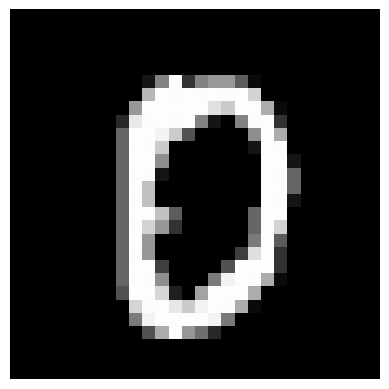

In [ ]:
#@title MNIST Dataset loading
batch_size=128
train_dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)
even_indices = [i for i, (_, label) in enumerate(train_dataset) if label % 2 == 0]
even_dataset = Subset(train_dataset, even_indices)
data_loader = DataLoader(even_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
images, labels = next(iter(data_loader))
x0 = images[0]
x0 = x0.unsqueeze(0).to(device)
plt.imshow(x0.squeeze().cpu(), cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
#@title masking operators
class GaussianDenoisingOperator:
    def forward(self, x):
        return x

class InpaintingOperator:
    def __init__(self, mask):
        self.mask = mask

    def forward(self, x):
        return self.mask * x

In [ ]:
#@title Tweedie Estimate
def compute_x0_hat(x_t, t, score):
    # Tweedie's formula
    sigma_t = marginal_prob_std_fn(t)
    sigma_t = sigma_t[:,None,None,None]
    return x_t + sigma_t**2 * score

#@title Measurement Loss
def measurement_loss(y, x0_hat, operator):
    y_hat = operator.forward(x0_hat)
    return ((y - y_hat)**2).sum()

#@title Gradient Calculation
def compute_gradient(x_t, y, operator, t):
    x_t.requires_grad_(True)
    score = score_model(x_t, t)
    x0_hat = compute_x0_hat(x_t,t, score)
    y_hat = operator.forward(x0_hat)
    loss = ((y - y_hat)**2).sum()
    grad = torch.autograd.grad(loss,x_t)[0]

    return grad, x0_hat

#@title Step size calculation
def compute_step_size(y,x0_hat,operator,zeta_prime):
    residual = y - operator.forward(x0_hat)
    return zeta_prime / (residual.norm() + 1e-8)

def reverse_sde_step(x_t, score, t, dt):
    g = diffusion_coeff_fn(t)
    if g.ndim == 0:
        g = g.view(1)
    g = g[:, None, None, None]
    noise = torch.randn_like(x_t)
    x_mean = x_t + g**2 * score * dt
    x = x_mean + g * torch.sqrt(dt) * noise
    return x, x_mean

In [ ]:
def dps_sampler(y,operator, num_steps=1000,zeta_prime=0.01):
    #torch.manual_seed(42)
    t_init = torch.ones(y.shape[0],device=device)
    init_std = marginal_prob_std_fn(t_init)

    init_std = init_std[:,None,None,None].to(y.device)

    x_t = torch.randn_like(y) * init_std
    time_steps = torch.linspace(1.0,1e-3,num_steps,device=device)
    dt = time_steps[0] - time_steps[1]

    for step, t in enumerate(time_steps):
        t_batch = torch.ones(x_t.shape[0],device=device) * t
        score = score_model(x_t,t_batch)
        x_prime,_ = reverse_sde_step(x_t,score,t,dt)
        grad, x0_hat = compute_gradient( x_t,y, operator,t_batch)
        step_size = compute_step_size(y,x0_hat,operator,zeta_prime).to(device)
        x_t = (x_prime- step_size * grad).detach()

    return x0_hat

In [ ]:
sigma_y = 0.2
y = x0 + sigma_y * torch.randn_like(x0).to(device)
operator = GaussianDenoisingOperator()
num_samples = 100
y_batch = y.repeat(num_samples, 1, 1, 1).to(device)
x_hat = dps_sampler(y_batch,operator,num_steps=1000,zeta_prime=0.1)

/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/3260956024.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=device)


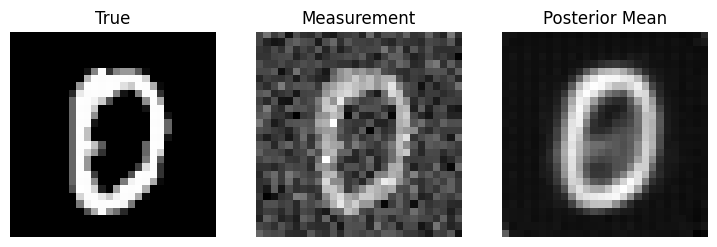

In [ ]:
posterior_mean = x_hat.mean(dim=0, keepdim=True)
fig, ax = plt.subplots(1,3, figsize=(9,3))

ax[0].imshow(x0[0,0].cpu(), cmap='gray')
ax[0].set_title("True")

ax[1].imshow(y[0,0].cpu(), cmap='gray')
ax[1].set_title("Measurement")

ax[2].imshow(posterior_mean[0,0].detach().cpu(),cmap='gray')
ax[2].set_title("Posterior Mean")

for a in ax:
    a.axis('off')
plt.savefig("Gaussian_posterior_mean_single_digit.png", dpi=300,  bbox_inches='tight')
plt.show()

In [ ]:
zeta_prime_list = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

num_samples = 100
y_batch = y.repeat(num_samples, 1, 1, 1).to(device)

posterior_means = {}

for zeta in zeta_prime_list:
    print(f"Running zeta_prime = {zeta}")
    x_hat = dps_sampler(y_batch,operator,num_steps=1000,zeta_prime=zeta)
    posterior_means[zeta] = (x_hat.mean(dim=0, keepdim=True).detach().cpu())
    print(f"Finished zeta_prime = {zeta}")

Running zeta_prime = 0.001


/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/3260956024.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=device)


Finished zeta_prime = 0.001
Running zeta_prime = 0.005
Finished zeta_prime = 0.005
Running zeta_prime = 0.01
Finished zeta_prime = 0.01
Running zeta_prime = 0.05
Finished zeta_prime = 0.05
Running zeta_prime = 0.1
Finished zeta_prime = 0.1
Running zeta_prime = 0.5
Finished zeta_prime = 0.5
Running zeta_prime = 1
Finished zeta_prime = 1
Running zeta_prime = 5
Finished zeta_prime = 5
Running zeta_prime = 10
Finished zeta_prime = 10


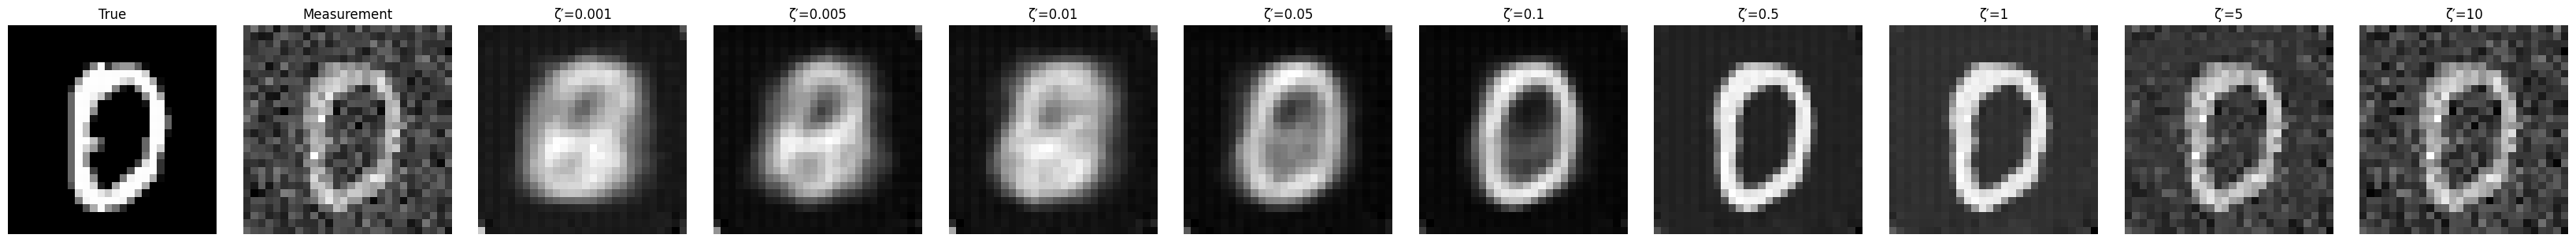

In [ ]:
import matplotlib.pyplot as plt

ncols = len(zeta_prime_list) + 2
fig, ax = plt.subplots(1, ncols, figsize=(3*ncols, 3))
# True image
ax[0].imshow(x0[0,0].detach().cpu().numpy(),cmap='gray')
ax[0].set_title("True")
# Measurement
ax[1].imshow(y[0,0].detach().cpu().numpy(),cmap='gray')
ax[1].set_title("Measurement")
# Posterior means
for i, zeta in enumerate(zeta_prime_list):
    ax[i+2].imshow(posterior_means[zeta][0,0].detach().cpu().numpy(),cmap='gray')
    ax[i+2].set_title(f"ζ′={zeta}")
for a in ax:
    a.axis('off')

plt.tight_layout()
plt.savefig("Gaussian_posterior_mean_different_zeta_prime.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from skimage.metrics import structural_similarity as ssim
import math

def compute_ssim(x_true, x_pred):
    x_true = x_true.detach().squeeze().cpu().numpy()
    #x_pred = x_pred.squeeze().cpu().numpy()
    x_pred = x_pred.detach().squeeze().cpu().numpy()
    return ssim(x_true,x_pred,data_range=x_true.max() - x_true.min())

def psnr(x_true, x_pred, max_val=1.0):
    mse = torch.mean((x_true - x_pred) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val / math.sqrt(mse.item()))

In [ ]:
metrics = {}

for zeta in zeta_prime_list:
    posterior_mean = posterior_means[zeta]
    metrics[zeta] = {
        "PSNR": psnr(x0.cpu(), posterior_mean),
        "SSIM": compute_ssim(x0.cpu(), posterior_mean)
    }

for zeta in zeta_prime_list:
    print(
        f"ζ′={zeta:<6} "
        f"PSNR={metrics[zeta]['PSNR']:.2f} dB  "
        f"SSIM={metrics[zeta]['SSIM']:.4f}"
    )

ζ′=0.001  PSNR=11.69 dB  SSIM=0.2826
ζ′=0.005  PSNR=11.61 dB  SSIM=0.2861
ζ′=0.01   PSNR=11.77 dB  SSIM=0.2893
ζ′=0.05   PSNR=13.37 dB  SSIM=0.4660
ζ′=0.1    PSNR=15.84 dB  SSIM=0.6724
ζ′=0.5    PSNR=23.83 dB  SSIM=0.9162
ζ′=1      PSNR=23.93 dB  SSIM=0.9109
ζ′=5      PSNR=17.57 dB  SSIM=0.7583
ζ′=10     PSNR=14.66 dB  SSIM=0.6957


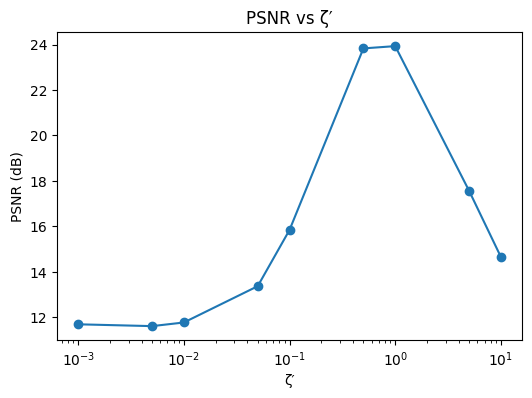

In [ ]:
psnr_values = [metrics[z]["PSNR"] for z in zeta_prime_list]

plt.figure(figsize=(6,4))
plt.plot(zeta_prime_list, psnr_values, marker='o')
plt.xscale('log')  # useful since zeta spans several orders
plt.xlabel("ζ′")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs ζ′")
plt.grid(False)
plt.savefig("PSNR_Gaussian_dps.png", dpi=300, bbox_inches="tight")
plt.show()

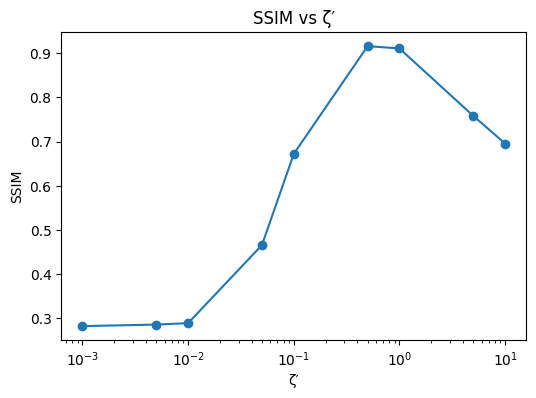

In [ ]:
ssim_values = [metrics[z]["SSIM"] for z in zeta_prime_list]

plt.figure(figsize=(6,4))
plt.plot(zeta_prime_list, ssim_values, marker='o')
plt.xscale('log')
plt.xlabel("ζ′")
plt.ylabel("SSIM")
plt.title("SSIM vs ζ′")
plt.grid(False)
plt.savefig("SSIM_Gaussian_dps.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
mask = (torch.rand_like(x0) < 0.20).float()
y_mask = mask * x0

operator = InpaintingOperator(mask)
num_samples = 100
y_batch_mask = y_mask.repeat(num_samples, 1, 1, 1).to(device)

x_hat_mask= dps_sampler(y_batch_mask,operator,num_steps=1000,zeta_prime=0.1)

/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/3260956024.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=device)


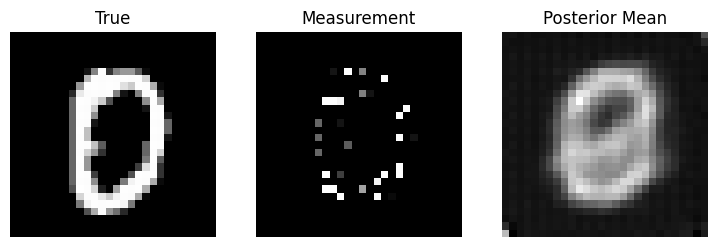

In [ ]:
posterior_mean_mask = x_hat_mask.mean(dim=0, keepdim=True)
fig, ax = plt.subplots(1,3, figsize=(9,3))

ax[0].imshow(x0[0,0].cpu(), cmap='gray')
ax[0].set_title("True")

ax[1].imshow(y_mask[0,0].cpu(), cmap='gray')
ax[1].set_title("Measurement")

ax[2].imshow(posterior_mean_mask[0,0].detach().cpu(),cmap='gray')
ax[2].set_title("Posterior Mean")

for a in ax:
    a.axis('off')
plt.savefig("Inpainting_posterior_mean_single_digit.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
zeta_prime_list = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

posterior_means_mask= {}

for zeta in zeta_prime_list:
    print(f"Running zeta_prime = {zeta}")
    x_hat_mask = dps_sampler(y_batch_mask,operator,num_steps=1000,zeta_prime=zeta)
    posterior_means_mask[zeta] = (x_hat_mask.mean(dim=0, keepdim=True).detach().cpu())
    print(x_hat_mask.shape)
    print(f"Finished zeta_prime = {zeta}")

Running zeta_prime = 0.001


/tmp/ipykernel_58/3260956024.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_58/3260956024.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=device)


torch.Size([100, 1, 28, 28])
Finished zeta_prime = 0.001
Running zeta_prime = 0.005
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 0.005
Running zeta_prime = 0.01
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 0.01
Running zeta_prime = 0.05
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 0.05
Running zeta_prime = 0.1
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 0.1
Running zeta_prime = 0.5
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 0.5
Running zeta_prime = 1
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 1
Running zeta_prime = 5
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 5
Running zeta_prime = 10
torch.Size([100, 1, 28, 28])
Finished zeta_prime = 10


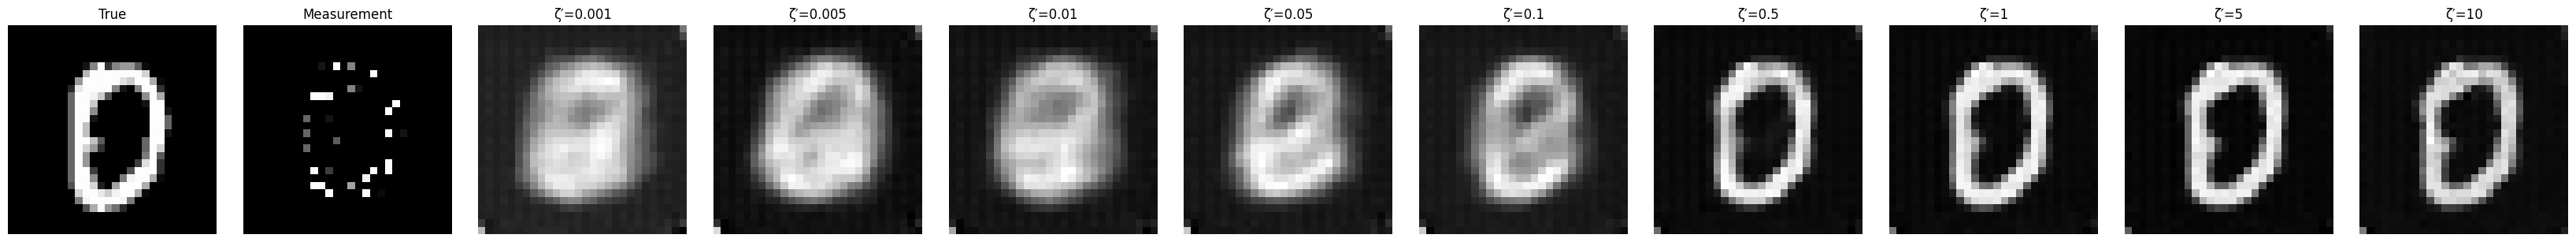

In [ ]:
ncols = len(zeta_prime_list) + 2
fig, ax = plt.subplots(1, ncols, figsize=(3*ncols, 3))
# True image
ax[0].imshow(x0[0,0].detach().cpu().numpy(),cmap='gray')
ax[0].set_title("True")
# Measurement
ax[1].imshow(y_mask[0,0].detach().cpu().numpy(),cmap='gray')
ax[1].set_title("Measurement")
# Posterior means
for i, zeta in enumerate(zeta_prime_list):
    ax[i+2].imshow(posterior_means_mask[zeta][0,0].detach().cpu().numpy(),cmap='gray')
    ax[i+2].set_title(f"ζ′={zeta}")
for a in ax:
    a.axis('off')

plt.tight_layout()
plt.savefig("Inpainting_posterior_mean_different_zeta_prime.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
metrics_msk = {}

for zeta in zeta_prime_list:
    posterior_mean_msk = posterior_means_mask[zeta]
    metrics_msk[zeta] = {
        "PSNR": psnr(x0.cpu(), posterior_mean_msk),
        "SSIM": compute_ssim(x0.cpu(), posterior_mean_msk)
    }

for zeta in zeta_prime_list:
    print(
        f"ζ′={zeta:<6} "
        f"PSNR={metrics_msk[zeta]['PSNR']:.2f} dB  "
        f"SSIM={metrics_msk[zeta]['SSIM']:.4f}"
    )

ζ′=0.001  PSNR=11.72 dB  SSIM=0.2828
ζ′=0.005  PSNR=11.97 dB  SSIM=0.3156
ζ′=0.01   PSNR=11.63 dB  SSIM=0.2744
ζ′=0.05   PSNR=12.03 dB  SSIM=0.3429
ζ′=0.1    PSNR=12.78 dB  SSIM=0.4255
ζ′=0.5    PSNR=19.75 dB  SSIM=0.8553
ζ′=1      PSNR=20.80 dB  SSIM=0.8717
ζ′=5      PSNR=20.30 dB  SSIM=0.8778
ζ′=10     PSNR=19.70 dB  SSIM=0.8478


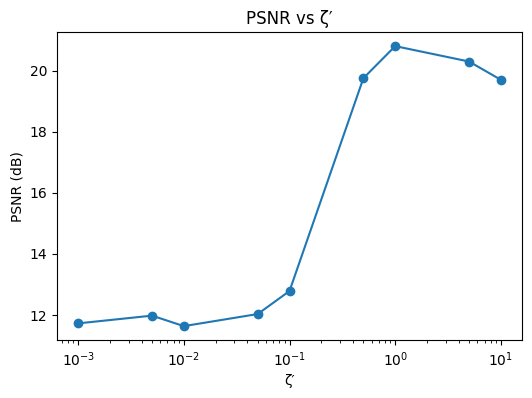

In [ ]:
psnr_values = [metrics_msk[z]["PSNR"] for z in zeta_prime_list]

plt.figure(figsize=(6,4))
plt.plot(zeta_prime_list, psnr_values, marker='o')
plt.xscale('log')  # useful since zeta spans several orders
plt.xlabel("ζ′")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs ζ′")
plt.grid(False)
plt.savefig("PSNR_Inpainting_dps.png", dpi=300, bbox_inches="tight")
plt.show()

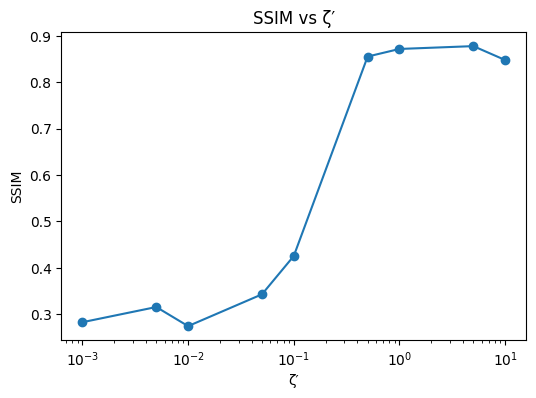

In [ ]:
ssim_values = [metrics_msk[z]["SSIM"] for z in zeta_prime_list]

plt.figure(figsize=(6,4))
plt.plot(zeta_prime_list, ssim_values, marker='o')
plt.xscale('log')
plt.xlabel("ζ′")
plt.ylabel("SSIM")
plt.title("SSIM vs ζ′")
plt.grid(False)
plt.savefig("SSIM_Inpainting_dps.png", dpi=300, bbox_inches='tight')
plt.show()